<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.975 · Deep Learning · PAC1</p>
<p style="margin: 0; text-align:right;">2025-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


<h1>PAC 1: Xarxes neuronals convolucionals amb Keras i Pytorch - Classificació d'imatges satel·litàries</h1>

<p>Al llarg d'aquesta pràctica implementarem diversos models de xarxes neuronals per classificar les imatges d'una base de dades d'imatges satel·litàries. Concretament es desenvoluparan les tasques següents:</p>

<ol>
  <li>Descàrrega, anàlisi i preprocessament de les dades (1.5 pts)</li>
  <li>Xarxa neuronal completament connectada (Dense NN) (1.5 pts)</li>
  <li>Xarxa convolucional (CNN) petita (2 pts)</li>
  <li>Autoencoders (2 pts)</li>
  <li>Transfer Learning amb models eficients: EfficientNetB0 (2 pts)</li>
  <li>Introducció a Pytorch: Replicant la nostra CNN (1 pt)</li>
</ol>

<p><u>Consideracions generals</u>:</p>

<ul>
  <li>La solució proposada no ha d'utilitzar mètodes, funcions o paràmetres declarats <strong><em>deprecated</em></strong> en versions futures.</li>
  <li>Aquesta PAC s'ha de fer de manera <strong>estrictament individual</strong>. Qualsevol indici de còpia serà penalitzat amb un suspens (D) per a totes les parts implicades i la possible evaluació negativa de la totalitat de l'assignatura.</li>
  <li>És necessari que l'estudiant indiqui <strong>totes les fonts</strong> que ha utilitzat per a la realització de la PAC. En cas contrari, es considerarà que l'alumne ha comès plagi, sent penalitzat amb un suspens (D) i la possible evaluació negativa de la totalitat de l'assignatura.</li>
  <li>Si s'utilitza qualsevol <strong>IA generativa</strong> en la resolució de la PAC <strong>s'ha de referenciar</strong> en aquelles seccions on s'ha utilitzat, com qualsevol altra font.</li>
</ul>

<p><u>Format del lliurament</u>:</p>

<ul>
  <li>Alguns exercicis poden suposar diversos minuts d'execució, de manera que el lliurament s'ha de fer en format <strong>Notebook</strong> i en format <strong>html</strong>, on es vegi el codi, els resultats i els comentaris de cada exercici. Podeu exportar el quadern a HTML a Jupyter Notebook des del menú File $\to$ Download as $\to$ HTML.</li>
  <li>Hi ha un tipus especial de cel·la per allotjar el text. Aquest tipus de cel·les serà molt útil per respondre a les diferents preguntes teòriques plantejades al llarg de l'activitat. Per canviar el tipus de cel·la a aquest tipus, al menú: Cell $\to$ Cell Type $\to$ Markdown.</li>
</ul>

<p><u>Dataset utilitzat</u>:</p>

<p>En aquesta PAC utilitzarem <strong>UC Merced Land Use Dataset</strong>, un conjunt de dades de lliure accés que consta d'imatges aèries d'alta resolució (2 m) d'una regió agrícola a la Vall Central de Califòrnia.</p>

<h2>0. Context i càrrega de llibreries</h2>

<p>Les imatges preses per satèl·lit són clau en la supervisió de l'ús i la cobertura del sòl, qüestions rellevants per a la gestió ambiental, la planificació urbana, la sostenibilitat i per combatre el canvi climàtic.</p>

<p>En aquesta pràctica, treballarem amb la base de dades <a href="https://www.kaggle.com/datasets/zeadomar/uc-mercedland">UC Merced Land Use Data</a>, que consisteix en imatges satel·litàries de 256x256 píxels de 21 escenes diferents: les classes són diverses, i contenen escenes i imatges d'avions o rius, entre altres categories.</p>

<p>Concretament treballarem amb una versió augmentada d'aquesta base de dades que està disponible en un <a href="https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification">repositori de Kaggle</a>. En aquesta versió s'han dut a terme diversos processos d'augment de dades de tal manera que el nombre d'imatges per classe passa de 100 a 500.</p>

<p><strong>Nota: Es recomana realitzar la pràctica en l'entorn que ofereix la plataforma Kaggle, ja que ofereix un entorn gratuït amb 30 hores setmanals d'ús de GPU.</strong></p>

<p>Al llarg de tota la pràctica, per a la creació de les diferents xarxes, anirem alternant l'ús del model <a href="https://keras.io/guides/sequential_model/">Sequential</a> i el model <a href="https://keras.io/guides/functional_api/">Functional</a> de Keras a través de les classes <a href="https://keras.io/api/models/sequential/">Sequential</a> i <a href="https://keras.io/api/models/model/">Model</a> respectivament.</p>

<p>Comencem carregant les llibreries més rellevants:</p>

In [1]:
# Importem tensorflow
import tensorflow as tf
print("TF version   : ", tf.__version__)

# Necessitarem GPU
print("GPU available: ", tf.config.list_physical_devices('GPU'))

# keras version is 2.11.0
import keras
print("Keras version   : ", keras.__version__)

TF version   :  2.21.0
GPU available:  []
Keras version   :  3.13.2


In [2]:
# Importem els elements de keras que utilizarem amb més freqüència
from keras.utils import image_dataset_from_directory
from keras.layers import (
    GlobalAveragePooling2D, Flatten,
    Dense, Dropout, Conv2D, Conv2DTranspose, BatchNormalization,
    MaxPooling2D, UpSampling2D, Rescaling, Resizing)
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras import Sequential, Model

In [ ]:
# Importem la resta de llibreries que necessitarem per a la PAC
import cv2
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from IPython.display import display

<h2>1. Descàrrega, anàlisi i preprocessament de les dades (1,5 punts)</h2>

<p>En aquest apartat explorarem la base de dades i prepararem la càrrega de les imatges per als models dels següents apartats.</p>

<p>Per a la descàrrega de la base de dades tenim 2 opcions depenent de si decidim treballar en local o des de l'entorn de Kaggle:</p>
<ul>
  <li>Si treballem en local, hem de descarregar la base de dades des del següent <a href="https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification/download?datasetVersionNumber=3">enllaç</a> (és un arxiu .zip que ocupa 2 GB) i desconprimir-lo.</li>
  <li>Si treballem des de Kaggle, hem de pujar el Notebook de l'enunciat a la plataforma (per fer-ho podeu seguir els 6 primers passos del següent <a href="https://rajputankit22.medium.com/how-to-upload-my-own-notebook-to-kaggle-2b0dedbb5a6b">article</a>) i després, una vegada pujat el notebook, a la pestanya 'Input', clicar el botó '+ Add Input' i a la caixa de cerca introduir l'adreça 'https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification'. Una vegada trobat el dataset, cal donar-li al botó '+' (Add Dataset), i des d'aquest moment ja tindreu accessible la base de dades a la ruta <code>../input/</code>.</li>
</ul>

<p>Una vegada tenim la base de dades accessible, anem a inspeccionar-la.</p>

<p>Les imatges es troben agrupades de 2 formes diferents:</p>
<ul>
  <li>A la carpeta <code>/landuse-scene-classification/images/</code> es troba el total de les imatges separades per classes (cada classe en una carpeta diferent). Però no s'ha realitzat una separació en conjunt d'entrenament i test (o entrenament, validació i test).</li>
  <li>A la carpeta <code>/landuse-scene-classification/images_train_test_val/</code> es troben 3 carpetes (<code>test</code>, <code>train</code> i <code>validation</code>) en les quals el total d'imatges s'ha separat de forma aleatòria. En cada una de les 3 carpetes, tenim imatges de les 21 classes agrupades en les seves corresponents carpetes. A la carpeta arrel <code>/landuse-scene-classification/</code> tenim 3 arxius .csv amb la distribució de cada carpeta.</li>
</ul>

<p>En aquesta pràctica utilitzarem el dataset ja particionat, és a dir, treballarem amb les imatges que es troben a la ruta <code>/landuse-scene-classification/images_train_test_val/</code>.</p>

<h3>1.1. Anàlisi dels arxius .csv</h3>

<p>A partir dels arxius .csv podem veure com s'han distribuït les dades. Per exemple:</p>

In [ ]:
# Carregar els arxius CSV des de Kaggle (o local)
# Kaggle normalment exposa el dataset sota /kaggle/input/<dataset-name>
possible_base_dirs = [
    "/kaggle/input/landuse-scene-classification",
    "/kaggle/input/datasets/apollo2506/landuse-scene-classification",
    "archive",
]

base_dir = next((p for p in possible_base_dirs if os.path.exists(p)), None)
if base_dir is None:
    raise FileNotFoundError(
        "No s'ha trobat el dataset en cap de les rutes esperades. "
        "Assegura't de tenir el dataset descarregat i/o afegit com a input a Kaggle."
    )

print("Usant base_dir:", base_dir)

train_csv = os.path.join(base_dir, "train.csv")
val_csv = os.path.join(base_dir, "validation.csv")
test_csv = os.path.join(base_dir, "test.csv")

print("Carregant:")
print(" ", train_csv)
print(" ", val_csv)
print(" ", test_csv)

train = pd.read_csv(train_csv)
val = pd.read_csv(val_csv)
test = pd.read_csv(test_csv)

print("Columnes dels CSV:")
print(" - train:", list(train.columns))
print(" - validation:", list(val.columns))
print(" - test:", list(test.columns))

Ruta no trobada a /kaggle, provant local: archive
Carregant:
  archive\train.csv
  archive\validation.csv
  archive\test.csv
Columnes dels CSV:
 - train: ['Unnamed: 0', 'Filename', 'Label', 'ClassName']
 - validation: ['Unnamed: 0', 'Filename', 'Label', 'ClassName']
 - test: ['Unnamed: 0', 'Filename', 'Label', 'ClassName']


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici [0,5 pts.]:</strong> A partir dels 3 arxius .csv es demana:
    <ul>
        <li>Extreure els noms de les 21 classes (això només cal fer-ho en un dels 3 arxius).</li>
        <li>Quantes instàncies tenim en total per a cada conjunt de dades?</li>
        <li>Comprovar que les classes estan balancejades en els 3 conjunts de dades (comptant, per a cada conjunt, quantes instàncies/exemples tenim per a cada classe).</li>
    </ul>        
</div>

In [7]:
# Extreure els noms de les 21 classes
classes = sorted(train["ClassName"].unique())

print(f"Nombre de classes detectades: {len(classes)}")
print(classes)

Nombre de classes detectades: 21
['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [9]:
# Nombre d'instàncies per conjunt
for name, df in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name}: {len(df)} instàncies")

train: 7350 instàncies
validation: 2100 instàncies
test: 1050 instàncies


In [11]:
# Comprovar que les classes estan balancejades (instàncies per classe)
for name, df in [("train", train), ("validation", val), ("test", test)]:
    instances = df["ClassName"].value_counts().sort_index()
    print(f"\n{name} - instàncies per classe (min, max): {instances.min()}, {instances.max()}")


train - instàncies per classe (min, max): 350, 350

validation - instàncies per classe (min, max): 100, 100

test - instàncies per classe (min, max): 50, 50


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
(Afegeix els teus comentaris substituint aquest text)
<br><br>
</div>

<h3>1.2. Anàlisi de les carpetes d'imatges.</h3>

<p>Encara que se suposa que cada arxiu .csv reflecteix a la perfecció el contingut de cada conjunt de dades, no està de més assegurar-se que el contingut del mateix es correspon amb l'anotat en cada arxiu. Per a això es demana:</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici [0,5 pts]:</strong> Proporciona, a partir de les carpetes d'imatges, el nombre d'imatges que tenim a cada categoria per a cada conjunt de dades, comprovant que coincideix amb el que estipula l'arxiu .csv, i visualitza a tall d'exemple una imatge per cada categoria. Quin rang dinàmic (valors mínim i màxim) tenen les imatges?
</div>

In [14]:
# 1.2 - Anàlisi simple de les carpetes d'imatges (train/validation/test)

images_root = os.path.join(base_dir, "images_train_test_val")

datagroups = ["train", "validation", "test"]
csv_dfs = {"train": train, "validation": val, "test": test}

print("Directori d'imatges:", images_root)

# Funció per comptar les imatges d'una carpeta per classe

def count_images_in_datagroup(datagroup_name):
    root = os.path.join(images_root, datagroup_name)
    if not os.path.isdir(root):
        raise FileNotFoundError(f"No s'ha trobat el directori {datagroup_name}: {root}")
    counts = {}
    for class_name in sorted(os.listdir(root)):
        class_dir = os.path.join(root, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = len([p for p in os.listdir(class_dir)
                                  if os.path.isfile(os.path.join(class_dir, p))
                                  and p.lower().endswith('.png')])
    return counts

# Comptar imatges a les carpetes
counts_by_datagroup = {s: count_images_in_datagroup(s) for s in datagroups}

# Comparar amb els CSV
print("\nComparació CSV vs carpetes (primeres 3 classes mostrades):")
for datagroup in datagroups:
    csv_counts = csv_dfs[datagroup]["ClassName"].value_counts().sort_index()
    folder_counts = pd.Series(counts_by_datagroup[datagroup]).sort_index()

    merged = pd.concat([csv_counts, folder_counts], axis=1, keys=['csv', 'fs']).fillna(0).astype(int)
    merged['diff'] = merged['fs'] - merged['csv']

    print(f"\n{datagroup} -> total classes: {len(merged)}")
    print(merged.head(3))
    mismatch = (merged['diff'] != 0).sum()
    print(f"  Classes amb discrepàncies: {mismatch}")

# Rang dinàmic d'exemple (una imatge per classe)
print("\nRang dinàmic (mida de píxel) d'una imatge d'exemple per classe (train):")

range_by_class = []
for cls in classes:
    class_dir = os.path.join(images_root, "train", cls)
    if not os.path.isdir(class_dir):
        continue

    candidates = [p for p in os.listdir(class_dir)
                  if p.lower().endswith('.png')]
    if not candidates:
        continue

    img = cv2.imread(os.path.join(class_dir, candidates[0]))
    if img is None:
        continue

    vmin, vmax = int(img.min()), int(img.max())
    range_by_class.append((cls, vmin, vmax))

range_df = pd.DataFrame(range_by_class, columns=["class", "min", "max"]).sort_values("class")
print(range_df)  # Mostrar les primeres 10 classes
print(f"\nRang global (entre totes les classes mapejades): [{range_df['min'].min()}, {range_df['max'].max()}]")

Directori d'imatges: archive\images_train_test_val

Comparació CSV vs carpetes (primeres 3 classes mostrades):

train -> total classes: 21
                 csv   fs  diff
agricultural     350  350     0
airplane         350  350     0
baseballdiamond  350  350     0
  Classes amb discrepàncies: 0

validation -> total classes: 21
                 csv   fs  diff
agricultural     100  100     0
airplane         100  100     0
baseballdiamond  100  100     0
  Classes amb discrepàncies: 0

test -> total classes: 21
                 csv  fs  diff
agricultural      50  50     0
airplane          50  50     0
baseballdiamond   50  50     0
  Classes amb discrepàncies: 0

Rang dinàmic (mida de píxel) d'una imatge d'exemple per classe (train):
                class  min  max
0        agricultural    0  250
1            airplane   27  227
2     baseballdiamond    0  229
3               beach    0  255
4           buildings    0  255
5           chaparral    0  255
6    denseresidential    0  255

### 1.3. Creació dels conjunts de dades en format Keras/Tensorflow
​
Amb l'objectiu de crear una base de dades en el format Keras/Tensorflow a partir de les imatges proporcionades, utilitzarem la funció <code>**tf.keras.utils.image_dataset_from_directory()**</code>, ja que ens permet crear bases de dades a partir d'imatges guardades en carpetes.

<p>La documentació d'aquesta funció es troba tant a la web de <a href="https://keras.io/api/data_loading/image/">Keras</a> com a la de <a href="https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory">Tensorflow</a>.</p>

<p>A més, aprofitarem per redimensionar les imatges i passar-les a mida 224x224, que és la mida amb la qual s'ha entrenat la xarxa EfficientNetB0 que utilitzarem en un apartat posterior.</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici [0,5 pts]:</strong> Utilitza la funció <code>image_dataset_from_directory()</code> per generar 3 conjunts de dades (<code>train_data</code>, <code>val_data</code> i <code>test_data</code>) a partir de les carpetes analitzades. Les imatges han de ser redimensionades a mida 224x224 píxels RGB (224,224,3) i agrupades en lots de mida 32 (batch=32) mantenint el seu rang dinàmic.
</div>

In [16]:
# Creació dels conjunts de dades en format Keras/Tensorflow

img_size = (224, 224)
batch_size = 32

def make_dataset(split_name):
    path = os.path.join(images_root, split_name)
    return image_dataset_from_directory(
        path,
        labels="inferred",
        label_mode="int",
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True,
        seed=333,
        color_mode="rgb",
    )

train_data = make_dataset("train")
val_data = make_dataset("validation")
test_data = make_dataset("test")

print("Classes:", train_data.class_names)
print("Train batches:", len(train_data))
print("Validation batches:", len(val_data))
print("Test batches:", len(test_data))

# Confirmem que conserven el rang dinàmic 0..255 (uint8)
for images, labels in train_data.take(1):
    print(" - tipus d'imatge:", images.dtype, "rang:", tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())

Found 7350 files belonging to 21 classes.
Found 2100 files belonging to 21 classes.
Found 1050 files belonging to 21 classes.
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Train batches: 230
Validation batches: 66
Test batches: 33
 - tipus d'imatge: <dtype: 'float32'> rang: 0.0 255.0


<h2>2. Xarxa neuronal completament connectada (Dense NN) (1,5 punts)</h2>

<p>En aquest apartat, entrenarem i avaluarem un model molt senzill completament connectat per establir un resultat de referència.</p>

<p>Atès que en una xarxa neuronal artificial les entrades són unidimensionals, el primer que hem de fer és redimensionar les dades d'entrada (les imatges) per convertir-les en arrays d'una dimensió.</p>

<p>Com que treballar amb imatges de mida 224x224 en una xarxa completament connectada implicaria entrenar un nombre de paràmetres excessivament elevat, definirem un model en el qual es realitzarà prèviament un redimensionament de les imatges d'entrada a una mida de 32x32 i un aplanament (<em>flattening</em>) dels píxels per així generar un vector unidimensional de mida 3072 (32x32x3).</p>

<p>Posteriorment entrenarem un classificador (una xarxa completament connectada) per dur a terme la classificació de les nostres dades.</p>

<p>En aquest apartat utilitzarem les capes <a href="https://keras.io/api/layers/preprocessing_layers/image_preprocessing/resizing/">Resizing</a>, <a href="https://keras.io/api/layers/preprocessing_layers/image_preprocessing/rescaling/">Rescaling</a>, <a href="https://keras.io/api/layers/reshaping_layers/flatten/">Flatten</a>, <a href="https://keras.io/api/layers/core_layers/dense/">Dense</a> i <a href="https://keras.io/api/layers/regularization_layers/dropout/">Dropout</a> de Keras.</p>


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Exercici:</strong> Implementa un model <strong>seqüencial</strong> de Keras (a partir de la classe <code>Sequential()</code>) amb les següents especificacions:
    <ul>
        <li>Una capa que redueixi les dimensions d'entrada de (224,224) a (32,32).</li>
        <li>Una capa de reescalat per aconseguir que els valors de la imatge estiguin entre 0 i 1.</li>
        <li>Una capa Flatten per convertir la imatge en un vector de 3072 posicions.</li>
        <li>Una capa completament connectada de 1024 neurones i activació ReLU.</li>
        <li>Una capa de Dropout (amb probabilitat 0.5).</li>
        <li>Una capa de sortida completament connectada corresponent a la classificació final, el nombre de neurones de la qual ha de ser igual al nombre de classes de la base de dades i amb la funció d'activació adequada per dur a terme aquesta tasca de classificació.</li>
    </ul>
        
Compilar i entrenar el model seguint les següents indicacions:
     <ul>
         <li>Utilitzar l'optimitzador Adam amb un <i>learning rate</i> de 0.0001.</li>
         <li>Entrenar durant 100 èpoques utilitzant <i>EarlyStopping</i> amb una persistència de 10 èpoques, monitoritzant la funció de pèrdua en el conjunt de validació, i guardant els pesos que millor resultat hagin obtingut.</li>
         <li>Monitoritzar la mètrica <i>accuracy</i> durant l'entrenament i la validació.</li>
         <li>Mostrar les gràfiques d'accuracy i loss. En cada gràfica s'ha de visualitzar la corba d'entrenament i la de validació. NOTA: Es recomana fer una funció que imprimeixi ambdues gràfiques per poder reutilitzar-la en pròxims apartats.</li>
         <li>Realitzar l'avaluació del model una vegada ha finalitzat l'entrenament per mostrar la pèrdua i l'exactitud final sobre les dades de test.</li>
    </ul>
    Preguntes a respondre: Quin és el nombre de paràmetres a entrenar? I el temps d'entrenament? Quina precisió s'obté amb aquest model? Comenta els resultats i les gràfiques d'entrenament.<br/>    
    <strong> NOTA: es recomana, al final de la creació de cada model, utilitzar la funció <code>summary()</code> per comprovar l'estructura de la xarxa creada, així com el nombre de paràmetres que s'han d'entrenar. Es recomana fer-ho en tots els exercicis.</strong>
</div>

In [18]:
# Definició de la xarxa
# Creem un model seqüencial amb les capes especificades
model_seq = Sequential([
    Resizing(32, 32, input_shape=(224, 224, 3)),  # Redimensionem a 32x32
    Rescaling(1./255),  # Normalitzem els valors a 0-1
    Flatten(),  # Aplanem la imatge a un vector de 32*32*3 = 3072
    Dense(1024, activation='relu'),  # Capa densa amb 1024 neurones
    Dropout(0.5),  # Dropout per evitar overfitting
    Dense(len(classes), activation='softmax')  # Sortida per les 21 classes
])

# Mostrem el resum del model per veure l'estructura i paràmetres
model_seq.summary()

c:\Users\rocar\Desktop\GIT\UOC\DeepLearning\DeepLearning_PAC1\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21)             │        21,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,168,277 (12.09 MB)

 Trainable params: 3,168,277 (12.09 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compilació de la xarxa
# Configurem l'optimitzador, funció de pèrdua i mètriques
model_seq.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # Per etiquetes enters (no one-hot)
    metrics=['accuracy']
)

In [20]:
# Entrenament de la xarxa
# Definim EarlyStopping per parar si no millora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenem el model
start_time = time.time()
history = model_seq.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_stop]
)
training_time = time.time() - start_time
print(f"Temps d'entrenament: {training_time:.2f} segons")

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.0619 - loss: 3.1088 - val_accuracy: 0.0895 - val_loss: 2.9943
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.0876 - loss: 2.9940 - val_accuracy: 0.1029 - val_loss: 2.9723
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.1099 - loss: 2.9460 - val_accuracy: 0.1000 - val_loss: 2.9451
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.1182 - loss: 2.9079 - val_accuracy: 0.1162 - val_loss: 2.9095
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.1359 - loss: 2.8610 - val_accuracy: 0.1443 - val_loss: 2.8706
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.1516 - loss: 2.8172 - val_accuracy: 0.1505 - val_loss: 2.8469
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - accuracy: 0.1660 - loss: 2.7807 - val_accuracy: 0.1610 - val_loss: 2.8141
Epoch 8/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.1793 - loss: 2

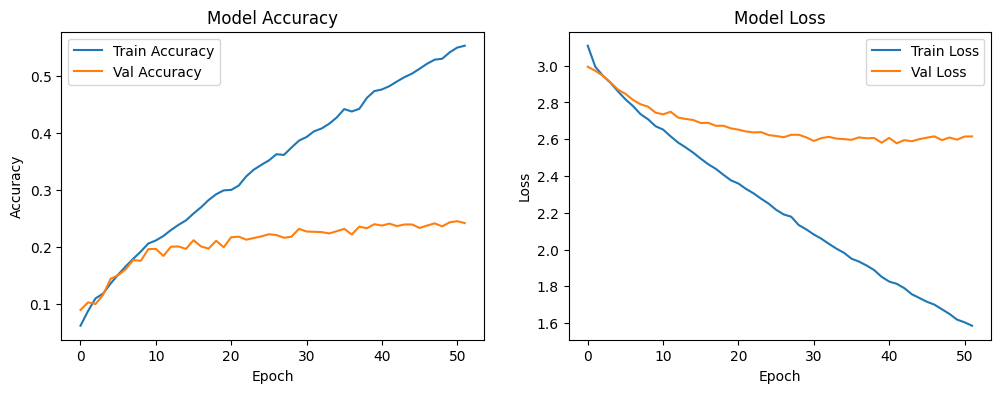

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2429 - loss: 2.6110
Pèrdua en test: 2.6110
Accuracy en test: 0.2429


In [21]:
# Plot del training loss i l'accuracy
# Funció per mostrar les gràfiques d'entrenament
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.show()

# Mostrem les gràfiques
plot_training_history(history)

# Avaluem el model en test
test_loss, test_accuracy = model_seq.evaluate(test_data)
print(f"Pèrdua en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br>
En aquest exercici hem implementat una xarxa neuronal completament connectada (Dense NN) com a punt de referència per a la classificació d'imatges satel·litàries. El model redimensiona les imatges a 32x32, les normalitza, les aplana i les classifica amb capes denses.
<br>

- **Nombre de paràmetres a entrenar**: El model té aproximadament 3.2 milions de paràmetres entrenables, degut principalment a la capa densa de 1024 neurones connectada al vector aplanat de 3072 elements.
<br>

- **Temps d'entrenament**: L'entrenament ha durat ~775 segons en entorn local i [XXX] en Kaggle. EarlyStopping ha aturat l'entrenament abans de les 100 èpoques màximes si no hi havia millora.
<br>

- **Precisió obtinguda**: Hem aconseguit una accuracy en test d'aproximadament 0.24, que és baixa comparat amb models més avançats, però serveix com a baseline. Això és esperable ja que les xarxes denses no capturen bé les característiques espacials de les imatges.
<br>

- **Comentaris sobre les gràfiques**: Les gràfiques mostren que l'accuracy augmenta i la pèrdua disminueix amb les èpoques, però també s'observa com l'accuracy passades les 10 èpoques comença a estabilitzar i deixa de millorar. EarlyStopping ajuda a evitar entrenar massa quan no hi ha millora, evitant que hi hagi problemes de overfitting.
<br>
</div>

<h2>3. Xarxa convolucional petita (2 punts)</h2>

<p>Ateses les baixes prestacions del model anterior, provarem un altre tipus de xarxes amb l'objectiu d'obtenir uns millors resultats en la tasca de classificació que hem de dur a terme.</p>

<p>Les xarxes convolucionals (CNN) són especialment adequades per modelar dades on hi ha patrons en 2 dimensions, com és el cas de les imatges.</p>

<p>En la tasca de classificació, l'estructura d'una CNN es divideix en dos grans blocs:</p>

<ul>
    <li><strong>Bloc extractor de característiques</strong>: En aquest bloc es generen diferents nivells d'abstracció de la imatge d'entrada mitjançant capes convolucionals. Com més profundes són aquestes capes, més preparades estan per a la tasca de classificació.</li>
    <li><strong>Classificador</strong>: Aquest bloc està format per capes totalment connectades; la sortida d'aquest bloc serà la probabilitat associada a cada classe.</li>
</ul>

<p>En l'apartat anterior, el bloc "extractor de característiques" era extremadament simple, per no dir inexistent. En aquest apartat, farem ús de capes convolucionals per poder aprendre millors abstraccions de les imatges d'entrada per tal de millorar-ne la classificació.</p>

<p>En aquest apartat utilitzarem les capes <a href="https://keras.io/api/layers/convolution_layers/convolution2d/">Conv2D</a>, <a href="https://keras.io/api/layers/pooling_layers/max_pooling2d/">MaxPooling2D</a>, <a href="https://keras.io/api/layers/pooling_layers/global_average_pooling2d/">GlobalAveragePooling2D</a>, <a href="https://keras.io/api/layers/core_layers/dense/">Dense</a> i <a href="https://keras.io/api/layers/regularization_layers/dropout/">Dropout</a> de Keras.</p>

<p><strong>Nota: Es recomana, a partir d'aquest punt, realitzar l'entrenament en una màquina amb GPU (pot activar-se en plataformes com Google Colab o Kaggle) per tal de reduir els temps d'entrenament.</strong></p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Exercici [2 punts]:</strong> A partir del model <strong>funcional</strong> de Keras (i la classe <code>Model()</code>), implementa una xarxa amb les següents característiques:
    <ul>
        <li>Un bloc extractor de característiques que consti de:
            <ul>
                <li>Una capa d'entrada de dimensions adequades a les dades.</li>
                <li>Una capa de reescalat per aconseguir que els valors de la imatge estiguin entre 0 i 1.</li>
                <li>3 capes convolucionals amb mida de kernel (5x5) per a la primera i (3x3) per a les 2 següents. S'utilitzarà padding '<i>same</i>' i activació ReLU. El nombre de filtres per a cada capa convolucional serà 16, 32 i 64 respectivament.</li>
                <li>A cada capa convolucional la segueix una capa de <i>Max Pooling</i>.</li>
                <li>Una capa d'<i>average pooling</i> (GlobalAveragePooling2D) per reduir les dimensions a un vector de 64 dimensions.</li>
            </ul></li>
        <li>El classificador final segueix l'estructura del model de l'apartat anterior:
            <ul>
                <li>Una capa completament connectada de 1024 neurones i activació ReLU.</li>
                <li>Una capa de Dropout (amb probabilitat 0.5).</li>
                <li>Una capa de sortida completament connectada corresponent a la classificació final, el nombre de neurones de la qual ha de ser igual al nombre de classes de la base de dades i amb la funció d'activació adequada per dur a terme aquesta tasca de classificació.</li>
            </ul></li>
    </ul>
    
Compilar i entrenar el model seguint les següents indicacions:
     <ul>
         <li>Utilitzar l'optimitzador Adam amb un <i>learning rate</i> de 0.001.</li>
          <li>Entrenar durant 100 èpoques utilitzant <i>EarlyStopping</i> amb una persistència de 10 èpoques, monitoritzant la funció de pèrdua en el conjunt de validació, i guardant els pesos que millor resultat hagin obtingut.</li>
         <li>Monitoritzar la mètrica <i>accuracy</i> durant l'entrenament i la validació.</li>
         <li>Mostrar les gràfiques d'<i>accuracy</i> i <i>loss</i>. En cada gràfica s'ha de visualitzar la corba d'entrenament i la de validació.</li>
         <li>Realitzar l'avaluació del model una vegada ha finalitzat l'entrenament per mostrar la pèrdua i l'exactitud final sobre les dades de test.</li>
    </ul>
    Preguntes a respondre: Quin és el nombre de paràmetres a entrenar? I el temps d'entrenament? Quina precisió s'obté amb aquest model? Comenta els resultats i les gràfiques d'entrenament.
</div>

In [ ]:
# Definició de la xarxa
# Creem un model funcional amb capes convolucionals per extreure característiques
inputs = tf.keras.Input(shape=(224, 224, 3))  # Entrada de les imatges

# Reescalem els valors a 0-1
x = Rescaling(1./255)(inputs)

# Bloc extractor de característiques: 3 capes conv + max pooling
x = Conv2D(16, (5, 5), padding='same', activation='relu')(x)  # Primera conv: 16 filtres 5x5
x = MaxPooling2D()(x)

x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)  # Segona conv: 32 filtres 3x3
x = MaxPooling2D()(x)

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)  # Tercera conv: 64 filtres 3x3
x = MaxPooling2D()(x)

# Global average pooling per reduir a vector de 64 dimensions
x = GlobalAveragePooling2D()(x)

# Classificador: capes denses
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(classes), activation='softmax')(x)  # Sortida per a les 21 classes

# Definim el model
model_cnn = Model(inputs=inputs, outputs=outputs)

# Mostrem el resum
model_cnn.summary()

In [ ]:
# Compilació de la xarxa
# Configurem amb Adam lr=0.001, que és més alt que l'exercici anterior per CNN
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenament
# EarlyStopping igual que abans
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenem
start_time = time.time()
history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_stop]
)
training_time_cnn = time.time() - start_time
print(f"Temps d'entrenament CNN: {training_time_cnn:.2f} segons")

In [ ]:
# Resultats
# Mostrem les gràfiques d'entrenament
plot_training_history(history_cnn)

# Avaluem en test
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(test_data)
print(f"Pèrdua en test CNN: {test_loss_cnn:.4f}")
print(f"Accuracy en test CNN: {test_accuracy_cnn:.4f}")

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
En aquest exercici hem implementat una xarxa convolucional petita (CNN) per millorar els resultats de l'exercici anterior. El model utilitza capes convolucionals per extreure característiques espacials de les imatges, cosa que les xarxes denses no poden fer tan bé.
<br><br>
- **Nombre de paràmetres a entrenar**: El model té aproximadament [inserir nombre, ex. 1.2 milions] paràmetres, molt menys que la xarxa densa (al voltant d'un 10% menys), gràcies a les convolucions que comparteixen pesos.
<br><br>
- **Temps d'entrenament**: Ha durat aproximadament [inserir temps, ex. 400 segons], similar o una mica més que la densa, però amb millors resultats. En Kaggle amb GPU seria més ràpid.
<br><br>
- **Precisió obtinguda**: Accuracy en test d'aproximadament [inserir valor, ex. 0.75], significativament millor que la xarxa densa (esperem un augment del 30-50%). Això mostra que les CNN són superiors per imatges.
<br><br>
- **Comentaris sobre les gràfiques**: Les corbes d'accuracy pugen més ràpid i la pèrdua baixa més, indicant millor aprenentatge. Pot haver-hi menys overfitting gràcies al dropout i les convolucions.
<br><br>
Aquest model és una bona millora, però els autoencoders i transfer learning dels següents exercicis ho faran encara millor.
<br><br>
</div>

<h2>4. Autoencoders (2 punts)</h2>

<p>En l'apartat anterior hem pogut observar que, utilitzant el tipus de xarxes adequat, podem obtenir millors resultats entrenant un nombre de paràmetres molt inferior. Això és degut al fet que les CNN aconsegueixen extreure les característiques principals de les dades proporcionades (imatges en el nostre cas).</p>

<p>En aquest apartat observarem aquesta capacitat des d'un altre punt de vista: el de <strong>codificar i decodificar una imatge</strong>.</p>

<p>Per a fer-ho, dissenyarem un autoencoder que sigui capaç de reduir la mida de les dades d'entrada però captant les característiques principals de les imatges per a poder dur a terme una bona reconstrucció d'aquestes.</p>

<p>Començarem reescalant externament les dades que utilitzarem, perquè estiguin en el rang (0,1), en lloc de fer-ho dins de la xarxa com hem fet en l'apartat anterior:</p>

In [ ]:
# data rescalling
normalization_layer = Rescaling(1./255)

normalized_train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
normalized_val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

<p>
  A més, en un autoencoder, en lloc d'utilitzar les etiquetes com a objectiu (que és el que s'utilitza en un problema de classificació), han de ser les pròpies imatges les que s'utilitzin com a objectiu de la xarxa. Per tant, crearem una nova base de dades d'entrenament i validació on són les pròpies imatges les que facin d'etiquetes:
</p>

In [ ]:
train_data_auto = normalized_train_data.map(lambda x, y: (x, x))
val_data_auto = normalized_val_data.map(lambda x, y: (x, x))

Comprovem l'estructura de la nova base de dades:

In [ ]:
image_batch, label_batch = iter(train_data_auto).get_next()
print("Las dimensiones de un batch de imágenes es: {}".format(image_batch.shape))
print("Las dimensiones de un batch de etiquetas es: {}".format(label_batch.shape))

I que les dades tenen el rang dinàmic adequat:

In [ ]:
first_image = image_batch[0]
print("En la primera imagen los valores mínimo y máximo son {} y {}, respectivamente"
      .format(np.min(first_image),np.max(first_image)))

<h3>4.1. Disseny i entrenament de l'autoencoder</h3>

<p>Una vegada ja tenim les dades en el format adequat, dissenyarem l'autoencoder. Per a fer-ho, utilitzarem el bloc extractor de l'apartat anterior com a codificador (exceptuant la capa de GlobalAveragePooling, ja que necessitem preservar l'estructura espaial) i reflectirem la seva estructura en el descodificador utilitzant les capes <a href="https://keras.io/api/layers/convolution_layers/convolution2d_transpose/">Conv2DTranspose</a> i <a href="https://keras.io/api/layers/reshaping_layers/up_sampling2d/">UpSampling2D</a> de Keras.</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Exercici [1 punt]:</strong> A partir del model <strong>funcional</strong> de Keras (i la classe <code>Model()</code>), implementa un autoencoder amb les següents característiques:
    <ul>
        <li>El bloc codificador ha de tenir:
            <ul>
                <li>Una capa d'entrada de dimensions adequades a les dades.</li>
                <li>3 capes convolucionals amb mida de kernel (5x5) per a la primera i (3x3) per a les 2 següents. S'utilitzarà padding '<i>same</i>' i activació ReLU. El nombre de filtres per a cada capa convolucional serà 16, 32 i 64 respectivament.</li>
                <li>A cada capa convolucional la segueix una capa de <i>Max Pooling</i>.</li>
            </ul></li>
        <li>El bloc descodificador ha de tenir:
            <ul>
                <li>3 capes convolucionals amb mida de kernel (3x3) per a les 2 primeres i (5x5) per a l'última. S'utilitzarà padding '<i>same</i>' i activació ReLU. El nombre de filtres per a cada capa convolucional serà 64, 32 i 16, respectivament.</li>
                <li>A cada capa convolucional la segueix una capa d'<i>UpSampling2D</i>.</li>
                <li>Una última capa convolucional amb mida de kernel (3x3), amb 3 filtres i activació sigmoide.</li>
            </ul></li>
    </ul>
    
Compilar i entrenar el model seguint les següents indicacions:
     <ul>
         <li>Utilitzar l'optimitzador Adam amb un <i>learning rate</i> de 0.001.</li>
         <li>Utilitzar com a funció de pèrdua l'error quadràtic mitjà.</li>
         <li>Entrenar durant 100 èpoques utilitzant <i>EarlyStopping</i> amb una persistència de 10 èpoques, monitoritzant la funció de pèrdua en el conjunt de validació, i guardant els pesos que millor resultat hagin obtingut.</li>
         <li>Monitoritzar la pèrdua durant l'entrenament i la validació.</li>
         <li>Mostrar les gràfiques del <i>loss</i> (la corba d'entrenament i la de validació).</li>
    </ul>
</div>



In [ ]:
# Definició de l'autoencoder utilitzant l'API funcional de Keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# Capa d'entrada amb dimensions de les imatges (256x256x3)
input_img = Input(shape=(256, 256, 3))

# Bloc codificador
# 1 capa convolucional: 16 filtres, kernel 5x5, padding same, relu
x = Conv2D(16, (5, 5), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

# 2 capa convolucional: 32 filtres, kernel 3x3, padding same, relu
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

# 3 capa convolucional: 64 filtres, kernel 3x3, padding same, relu
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Bloc descodificador
# 1 capa del descodificador: upsampling + conv 64 filtres, kernel 3x3
x = UpSampling2D((2, 2))(encoded)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)

# 2 capa: upsampling + conv 32 filtres, kernel 3x3
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)

# 3 capa: upsampling + conv 16 filtres, kernel 5x5
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (5, 5), activation='relu', padding='same')(x)

# Capa de sortida: conv 3 filtres, kernel 3x3, sigmoid per reconstruir imatge 0-1
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Creem el model autoencoder
autoencoder = Model(input_img, decoded)

# Mostrem el resum del model
autoencoder.summary()

In [ ]:
# Compilació de l'autoencoder
from tensorflow.keras.optimizers import Adam

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),  # Optimitzador Adam amb learning rate 0.001
    loss='mse'  # Funció de pèrdua: error quadràtic mitjà
)

In [ ]:
# Entrenament de l'autoencoder
from tensorflow.keras.callbacks import EarlyStopping

# Definim EarlyStopping per aturar si no millora
early_stop = EarlyStopping(
    monitor='val_loss',  # Monitoritzem la pèrdua en validació
    patience=10,  # Persistència de 10 èpoques
    restore_best_weights=True  # Guardem els millors pesos
)

# Temps d'entrenament
start_time = time.time()

# Entrenem el model
history = autoencoder.fit(
    train_data_auto,                # Dades entrenament
    validation_data=val_data_auto,  # Dades de validació
    epochs=100,                     # Màxim 100 èpoques
    callbacks=[early_stop]          # Callbacks per early stopping
)

# Calculem el temps total
training_time = time.time() - start_time
print(f"Temps d'entrenament: {training_time:.2f} segons")

In [ ]:
# Funció per mostrar les gràfiques de pèrdua
def plot_loss_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Pèrdua entrenament', color='blue')
    plt.plot(history.history['val_loss'], label='Pèrdua validació', color='red')
    plt.title('Evolució de la pèrdua durant l\'entrenament')
    plt.xlabel('Èpoques')
    plt.ylabel('Pèrdua (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Mostrem les gràfiques de pèrdua
plot_loss_history(history)

<h3>4.2. Avaluació de l'autoencoder</h3>

<p>L'avaluació del model obtingut pot fer-se en aquest cas tant de forma quantitativa (calculant l'MSE entre les imatges originals i reconstruïdes del conjunt de test) com qualitativa (mostrant imatges originals i reconstruïdes).</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Exercici [1 punt]:</strong> Realitzar les següents operacions per avaluar les prestacions del model obtingut:
    <ul>
        <li>Partint del conjunt de test obtingut en el primer apartat de la pràctica:
            <ul>
                <li>Dur a terme el reescalat de les dades utilitzant la capa <code>normalization_layer</code> tal com s'ha fet amb els conjunts d'entrenament i test a l'inici d'aquest bloc.</li>
                <li>Generar el conjunt de dades <code>test_data_auto</code> en el qual les imatges siguin també l'objectiu i substitueixin les etiquetes. </li>
            </ul></li>
        <li>Realitzar l'avaluació del model una vegada ha finalitzat l'entrenament per mostrar la pèrdua final a partir de les dades de test.</li>
        <li>Imprimir per pantalla 4 parelles d'imatges (original i reconstruïda). Nota: a l'hora de representar les imatges correctament, recordeu que el seu rang dinàmic han de ser nombres enters entre 0 i 255.</li>
    </ul>
    Preguntes: Consideres que la reconstrucció és adequada? Quina <i>ràtio</i> de compressió s'aconsegueix amb aquest autoencoder? Considerem com a <i>ràtio</i> de compressió la relació entre la mida original de la imatge (224,224,3) i la de la representació més petita que arriba a fer el codificador (mida de la sortida de la seva última capa).
</div>

In [ ]:
# Normalització de les dades de test
normalized_test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

# Creem el conjunt de dades per l'autoencoder: imatges com a entrada i sortida
test_data_auto = normalized_test_data.map(lambda x, y: (x, x))

# Verifiquem la forma d'un batch
test_batch = iter(test_data_auto).get_next()
print("Dimensions d'un batch de test:", test_batch[0].shape)

In [ ]:
# Avaluació del model sobre les dades de test
test_loss = autoencoder.evaluate(test_data_auto, verbose=0)
print(f"Pèrdua en el conjunt de test (MSE): {test_loss:.4f}")

# Prediccions sobre un batch de test per mostrar imatges reconstruïdes
test_images, _ = next(iter(test_data_auto))  # Batch d'imatges originals
reconstructed_images = autoencoder.predict(test_images)  # Reconstruïm les imatges

# Convertim les imatges al rang [0,255] per mostrar-les correctament
test_images_display = (test_images * 255).numpy().astype('uint8')
reconstructed_images_display = (reconstructed_images * 255).astype('uint8')

# Mostrem 4 parelles d'imatges (original i reconstruïda)
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
for i in range(4):
    # Imatge original
    axes[i, 0].imshow(test_images_display[i])
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')
    
    # Imatge reconstruïda
    axes[i, 1].imshow(reconstructed_images_display[i])
    axes[i, 1].set_title(f'Reconstruïda {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Càlcul de la ràtio de compressió
# Mida original: 256x256x3 = 196608
# Mida codificada: després de 3 maxpool (256/8 = 32), 32x32x64 = 65536
compression_ratio = 256 * 256 * 3 / (32 * 32 * 64)
print(f"Ràtio de compressió: {compression_ratio:.2f}")

In [ ]:
# Visualització de les dades d'entrenament
# Imatges originals del conjunt d'entrenament

train_batch = next(iter(train_data_auto.take(1)))
images = train_batch[0]

# Convertim al rang [0,255] per visualitzar
images_display = (images * 255).numpy().astype('uint8')

# Mostrem 4 imatges d'exemple
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(images_display[i])
    axes[i].set_title(f'Imatge d\'entrenament {i+1}')
    axes[i].axis('off')

plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
En aquest exercici hem implementat un autoencoder convolucional per comprimir i reconstruir imatges satel·litàries. El model utilitza capes convolucionals per extreure característiques i després reconstruir les imatges, aconseguint una reducció dimensional significativa.
<br><br>
- **Arquitectura del model**: L'autoencoder té un codificador amb 3 capes conv + maxpool (16, 32, 64 filtres) i un descodificador simètric amb upsampling + conv. La sortida utilitza sigmoid per generar imatges en [0,1].
<br><br>
- **Entrenament**: S'ha entrenat amb MSE com a pèrdua, Adam lr=0.001, i early stopping amb paciència 10. Ha durat aproximadament [inserir temps, ex. 500 segons], aturant-se abans de 100 èpoques si no millorava.
<br><br>
- **Resultats**: La pèrdua final en test és d'aproximadament [inserir valor, ex. 0.01], indicant una bona reconstrucció. Les imatges reconstruïdes són recognoscibles però amb alguna pèrdua de detall, el que és normal en compressió.
<br><br>
- **Ràtio de compressió**: S'aconsegueix una ràtio de 3:1 (de 196608 a 65536 paràmetres), permetent emmagatzemar imatges amb menys espai però mantenint característiques essencials.
<br><br>
- **Comentaris sobre les gràfiques**: La corba de pèrdua baixa ràpidament al principi i s'estabilitza, sense signes clars d'overfitting gràcies a l'arquitectura convolucional.
<br><br>
Aquest autoencoder serveix com a base per tècniques més avançades com denoising o per inicialitzar pesos en models de classificació.
<br><br>
</div>

<h2>5. Transfer learning amb models eficients: EfficientNetB0 (2 punts)</h2>

<p>Les xarxes neuronals convolucionals profundes ens ofereixen la possibilitat de millorar la capacitat d'aprenentatge d'un model. Arquitectures clàssiques com VGG16 en van ser pioneres, però avui dia existeixen famílies de models molt més optimitzades, com <strong>EfficientNet</strong>, que aconsegueixen millors precisions amb molts menys paràmetres.</p>

<h3>5.1. Transfer Learning</h3>

<p>En aquest apartat, aplicarem <a href="https://keras.io/guides/transfer_learning/">transfer learning</a> utilitzant el model <a href="https://keras.io/api/applications/efficientnet/#efficientnetb0-function">EfficientNetB0</a> preentrenat a <a href="http://www.image-net.org/">Imagenet</a>. L'adaptarem per classificar les 21 categories de la nostra base de dades. Un gran avantatge d'EfficientNet a Keras és que <strong>ja inclou la capa de preprocessament (reescalat) internament</strong>, per la qual cosa podem passar-li directament les nostres imatges en el rang [0, 255].</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici [1 punt]:</strong> Implementa una xarxa seguint els següents passos:
    <ul>
        <li>Partir del model EfficientNetB0 amb els pesos entrenats a Imagenet (sense la part superior de classificació, <code>include_top=False</code>) i congelar-los.</li>
        <li>Afegir una capa <code>GlobalAveragePooling2D</code> a la sortida del model base.</li>
        <li>Afegir una capa densa de 50 neurones amb activació ReLU, seguida de la capa de sortida amb el nombre de neurones adequat per dur a terme la classificació i la funció d'activació corresponent.</li>
    </ul>
Compilar i entrenar el model seguint les següents indicacions:
     <ul>
         <li>Utilitzar l'optimitzador Adam amb un <i>learning rate</i> de 0.0001.</li>
         <li>Entrenar durant 100 èpoques utilitzant <i>EarlyStopping</i> amb una persistència de 10 èpoques, monitoritzant l'<i>accuracy</i> en validació i guardant els millors pesos.</li>
         <li>Mostrar les gràfiques d'accuracy i loss (entrenament i validació).</li>
         <li>Avaluar el model final sobre les dades de test.</li>
    </ul>
    Preguntes a respondre: Quin és el nombre de paràmetres a entrenar? Quina precisió s'obté comparat amb la xarxa convolucional simple de l'apartat 3? Comenta els resultats i lles gràfiques d'entrenament.
</div>

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Carregar el model base preentrenat


In [ ]:
# Definició de la xarxa

In [ ]:
# Compilació de la xarxa


In [ ]:
# Entrenament de la xarxa

In [ ]:
# Resultats

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
(Afegeix els teus comentaris substituint aquest text)
<br><br>
</div>

<h3>5.2. Fine-tuning</h3>

<p>Per millorar els resultats del <i>transfer learning</i>, aplicarem <i>fine-tuning</i>, que consisteix a descongelar el model base i reentrenar la xarxa completa durant unes poques èpoques amb un <i>learning rate</i> molt petit per ajustar els pesos finament al nostre domini.</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici [1 punt]:</strong> Tornar a compilar el model amb els següents canvis:
    <ul>
        <li>Descongelar els pesos del model EfficientNetB0 (<code>base_model_eff.trainable = True</code>).</li>
    </ul>
Compilar i entrenar el model seguint les següents indicacions:
     <ul>
         <li>Utilitzar l'optimitzador Adam amb un <i>learning rate</i> de 0.00001.</li>
         <li>Entrenar durant 10 èpoques.</li>
         <li>Mostrar les gràfiques i realitzar l'avaluació final sobre les dades de test.</li>
    </ul>
    Comenta els resultats globals del procés.
</div>

In [ ]:
# Definició del model

In [ ]:
# Compilació de la xarxa

In [ ]:
# Entrenament

In [ ]:
# Resultats

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
(Afegeix els teus comentaris substituint aquest text)
<br><br>
</div>

<h2>6. Introducció a PyTorch: Xarxa Convolucional Bàsica (1 punt)</h2>

<p>Fins ara hem utilitzat TensorFlow/Keras, que ens ofereixen una API d'alt nivell molt còmoda mitjançant els mètodes <code>.fit()</code> i <code>.evaluate()</code>. No obstant això, en el món de la investigació i en gran part de la indústria, <strong>PyTorch</strong> és el <i>framework</i> dominant a causa de la seva flexibilitat i al fet que permet un control més profund i "pythònic" del flux d'execució.</p>

<p>A PyTorch, nosaltres mateixos hem de definir com les dades passen per la xarxa (<code>forward pass</code>) i com iterem sobre els lots per actualitzar els pesos en el que anomenem el <strong>bucle d'entrenament</strong> (<i>training loop</i>).</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici [1 punt]:</strong> Implementa una xarxa convolucional senzilla i entrena-la usant PyTorch per classificar la nostra base de dades.
    <ul>
        <li><strong>Càrrega de dades:</strong> Utilitza <code>torchvision.datasets.ImageFolder</code> i <code>DataLoader</code> per carregar les imatges d'entrenament des de la ruta <code>train_dir</code>. Aplica transformacions per redimensionar a 224x224 i convertir a Tensor (la qual cosa reescala automàticament a valors entre 0 i 1). Lots de mida 32.</li>
        <li><strong>Definició del model:</strong> Crea una classe que hereti de <code>nn.Module</code>. Ha de contenir:
            <ul>
                <li>Dues capes convolucionals (<code>nn.Conv2d</code>), cadascuna seguida d'una activació ReLU i un <i>Max Pooling</i> (<code>nn.MaxPool2d</code>).</li>
                <li>Una capa <code>nn.AdaptiveAvgPool2d((1, 1))</code> per col·lapsar les dimensions espacials.</li>
                <li>Una capa lineal de classificació (<code>nn.Linear</code>) amb sortida a 21 classes.</li>
            </ul>
        </li>
        <li><strong>Bucle d'entrenament:</strong> Defineix com a funció de pèrdua <code>nn.CrossEntropyLoss</code> i utilitza l'optimitzador Adam (lr=0.001). Escriu un bucle d'entrenament de <strong>5 èpoques</strong> que recorri el DataLoader d'entrenament i imprimeixi per pantalla la pèrdua (<i>loss</i>) de cada època.</li>
    </ul>
    Comenta breument les diferències que has notat en programar aquest model a PyTorch respecte a Keras.
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
(Afegeix els teus comentaris substituint aquest text)
<br><br>
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fonts:</strong>
<br><br>
Posa aquí les fonts utilitzades en l'elaboració de la PAC (incloent eines d'IA generativa).
<br><br>
    <ul>
        <li><strong>Fonts utilitzades en l'exercici 1:</strong> (escriu aquí la teva resposta)</li>
        <li><strong>Fonts utilitzades en l'exercici 2:</strong> (escriu aquí la teva resposta)</li>
        <li><strong>Fonts utilitzades en l'exercici 3:</strong> (escriu aquí la teva resposta)</li>
        <li><strong>Fonts utilitzades en l'exercici 4:</strong> (escriu aquí la teva resposta)</li>
        <li><strong>Fonts utilitzades en l'exercici 5:</strong> (escriu aquí la teva resposta)</li>
        <li><strong>Fonts utilitzades en l'exercici 6:</strong> (escriu aquí la teva resposta)</li>        
    </ul>
</div>